# =========================================================
# IMPACT ANALYSIS - CLEAN FINAL WORKFLOW
# =========================================================

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind
sns.set_style("whitegrid")
sns.set_context("talk")

pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")

import textwrap


def wrap_school_name(name, width=12):
    if pd.isna(name):
        return name
    return "\n".join(textwrap.wrap(str(name), width=width))



# =========================================================
# 1. LOAD DATA
# =========================================================

baseline_path = r"C:\Users\Avikansh\Downloads\2026_Analysis\Baseline_Final.xlsx"
midline_path  = r"C:\Users\Avikansh\Downloads\2026_Analysis\Sironj_Midline_Final.xlsx"

baseline_df = pd.read_excel(baseline_path)
midline_df  = pd.read_excel(midline_path)

print("Raw Baseline shape:", baseline_df.shape)
print("Raw Midline shape:", midline_df.shape)


# =========================================================
# 2. STANDARDIZE COLUMNS
# =========================================================

def standardize_df(df):
    df = df.copy()

    # Clean column names
    df.columns = df.columns.str.strip().str.replace(" ", "_", regex=False)

    return df

baseline_df = standardize_df(baseline_df)
midline_df = standardize_df(midline_df)


# =========================================================
# 3. REMOVE FAKE / BLANK EXTRA ROWS
# =========================================================

score_cols = ['Reading_Calculated', 'Writing_Calculated', 'Numeracy_Calculated']

question_cols = [
    'Hindi_Reading_1', 'Hindi_Reading_2', 'Hindi_Reading_3',
    'Hindi_Reading_4', 'Hindi_Reading_5', 'Hindi_Reading_6',
    'Hindi_Reading_7',
    'Hindi_Writing_1', 'Hindi_Writing_2', 'Hindi_Writing_3', 'Hindi_Writing_4',
    'Numeracy_Q1', 'Numeracy_Q2', 'Numeracy_Q3', 'Numeracy_Q4', 'Numeracy_Q5',
    'Numeracy_Q6', 'Numeracy_Q7', 'Numeracy_Q8', 'Numeracy_Q9', 'Numeracy_Q10', 'Numeracy_Q11'
]

core_id_cols = ['Student_Name', 'School_Name', 'Grade']

def clean_valid_student_rows(df):
    df = df.copy()

    # convert calculated scores to numeric
    for col in score_cols + question_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

    # remove rows where all identity columns are missing
    df = df[~df[core_id_cols].isna().all(axis=1)].copy()

    # remove rows where Student_Name OR School_Name OR Grade is missing
    df = df[
        df['Student_Name'].notna() &
        df['School_Name'].notna() &
        df['Grade'].notna()
    ].copy()

    return df

baseline_df = clean_valid_student_rows(baseline_df)
midline_df = clean_valid_student_rows(midline_df)

print("Clean Baseline shape:", baseline_df.shape)
print("Clean Midline shape:", midline_df.shape)


# =========================================================
# 4. CLEAN TEXT / GROUP / GENDER / GRADE
# =========================================================

def clean_text_fields(df):
    df = df.copy()

    text_cols = ['Student_Name', 'School_Name', 'Group', 'Gender_(M/F)']
    for col in text_cols:
        if col in df.columns:
            df[col] = df[col].astype(str).str.strip()

    # Group mapping
    if 'Group' in df.columns:
        group_map = {
            'treatment': 'Treatment',
            'intervention': 'Treatment',
            'control': 'Control',
            'reference': 'Control',
            'general': 'General',
            'demo': 'General'
        }
        df['Group'] = df['Group'].str.lower().map(group_map).fillna(df['Group'])

    # Gender mapping
    if 'Gender_(M/F)' in df.columns:
        df['Gender_(M/F)'] = df['Gender_(M/F)'].str.upper().replace({
            'MALE': 'M',
            'FEMALE': 'F'
        })

    # Grade cleaning
    df['Grade'] = pd.to_numeric(df['Grade'], errors='coerce')
    df.loc[~df['Grade'].isin([1, 2, 3, 4, 5]), 'Grade'] = np.nan

    return df

baseline_df = clean_text_fields(baseline_df)
midline_df = clean_text_fields(midline_df)

# If your analysis is only for Grades 2-5, remove Grade 1 here
# baseline_df = baseline_df[baseline_df['Grade'].isin([2, 3, 4, 5])].copy()
# midline_df = midline_df[midline_df['Grade'].isin([2, 3, 4, 5])].copy()


# =========================================================
# 5. FEATURE ENGINEERING
# =========================================================

baseline_df['Overall_Score'] = (
    baseline_df['Reading_Calculated'] +
    baseline_df['Writing_Calculated'] +
    baseline_df['Numeracy_Calculated']
)

midline_df['Overall_Score'] = (
    midline_df['Reading_Calculated'] +
    midline_df['Writing_Calculated'] +
    midline_df['Numeracy_Calculated']
)

# Subject percentages
baseline_df['Reading_%'] = (baseline_df['Reading_Calculated'] / 27) * 100
baseline_df['Writing_%'] = (baseline_df['Writing_Calculated'] / 17) * 100
baseline_df['Numeracy_%'] = (baseline_df['Numeracy_Calculated'] / 36) * 100
baseline_df['Overall_%'] = (baseline_df['Overall_Score'] / 80) * 100

midline_df['Reading_%'] = (midline_df['Reading_Calculated'] / 27) * 100
midline_df['Writing_%'] = (midline_df['Writing_Calculated'] / 17) * 100
midline_df['Numeracy_%'] = (midline_df['Numeracy_Calculated'] / 36) * 100
midline_df['Overall_%'] = (midline_df['Overall_Score'] / 80) * 100



# baseline_df['Overall_%'] = (baseline_df['Overall_Score'] / 80) * 100
# midline_df['Overall_%'] = (midline_df['Overall_Score'] / 80) * 100


baseline_df['Overall_Tercile'] = pd.qcut(
    baseline_df['Overall_Score'],
    q=3,
    labels=['Low', 'Medium', 'High'],
    duplicates='drop'
)

midline_df['Overall_Tercile'] = pd.qcut(
    midline_df['Overall_Score'],
    q=3,
    labels=['Low', 'Medium', 'High'],
    duplicates='drop'
)

tercile_mapping = {
    'Low': 'Below Basic',
    'Medium': 'Basic',
    'High': 'Proficient'
}

baseline_df['Overall_Tercile'] = baseline_df['Overall_Tercile'].astype(str).str.strip().str.title()
midline_df['Overall_Tercile'] = midline_df['Overall_Tercile'].astype(str).str.strip().str.title()

baseline_df['Tercile_Label'] = baseline_df['Overall_Tercile'].map(tercile_mapping)
midline_df['Tercile_Label'] = midline_df['Overall_Tercile'].map(tercile_mapping)


# =========================================================
# 6. VALIDATION CHECK
# =========================================================

print("\nFinal valid baseline rows:", len(baseline_df))
print("Final valid midline rows:", len(midline_df))

print("\nMissing in baseline:")
print(baseline_df[['Student_Name', 'School_Name', 'Grade']].isna().sum())

print("\nMissing in midline:")
print(midline_df[['Student_Name', 'School_Name', 'Grade']].isna().sum())

Raw Baseline shape: (415, 36)
Raw Midline shape: (415, 36)
Clean Baseline shape: (375, 36)
Clean Midline shape: (300, 36)

Final valid baseline rows: 375
Final valid midline rows: 300

Missing in baseline:
Student_Name    0
School_Name     0
Grade           0
dtype: int64

Missing in midline:
Student_Name    0
School_Name     0
Grade           0
dtype: int64


In [3]:
baseline_df = clean_valid_student_rows(baseline_df)
midline_df = clean_valid_student_rows(midline_df)

print("Final valid baseline rows:", len(baseline_df))
print("Final valid midline rows:", len(midline_df))

Final valid baseline rows: 375
Final valid midline rows: 300


In [4]:
def add_pct_labels(ax, decimals=1):
    fmt = f'%.{decimals}f%%'
    for container in ax.containers:
        ax.bar_label(container, fmt=fmt, padding=3)

In [5]:
print(baseline_df[['Reading_Calculated', 'Writing_Calculated', 'Numeracy_Calculated']].max())
print(midline_df[['Reading_Calculated', 'Writing_Calculated', 'Numeracy_Calculated']].max())

Reading_Calculated     27
Writing_Calculated     17
Numeracy_Calculated    35
dtype: int64
Reading_Calculated     28
Writing_Calculated     17
Numeracy_Calculated    36
dtype: int64


In [6]:
# =========================================================
# 6. DESCRIPTIVE SUMMARY
# =========================================================

baseline_summary = baseline_df[
    ['Reading_Calculated', 'Writing_Calculated', 'Numeracy_Calculated', 'Overall_Score']
].describe().T

midline_summary = midline_df[
    ['Reading_Calculated', 'Writing_Calculated', 'Numeracy_Calculated', 'Overall_Score']
].describe().T

print("\nBaseline Summary")
print(baseline_summary)

print("\nMidline Summary")
print(midline_summary)

print("\nBaseline Group Distribution")
print(baseline_df['Group'].value_counts(dropna=False))

print("\nMidline Group Distribution")
print(midline_df['Group'].value_counts(dropna=False))

print("\nBaseline Tercile Distribution")
print(baseline_df['Tercile_Label'].value_counts(dropna=False))

print("\nMidline Tercile Distribution")
print(midline_df['Tercile_Label'].value_counts(dropna=False))



Baseline Summary
                     count       mean        std  min   25%   50%   75%   max
Reading_Calculated   375.0  13.925333   7.068025  0.0   9.0  14.0  19.5  27.0
Writing_Calculated   375.0   4.602667   4.878140  0.0   0.0   3.0   8.0  17.0
Numeracy_Calculated  375.0  12.952000   7.691431  0.0   7.0  12.0  18.0  35.0
Overall_Score        375.0  31.480000  17.525657  0.0  19.0  29.0  43.5  79.0

Midline Summary
                     count       mean        std  min   25%   50%   75%   max
Reading_Calculated   300.0  19.896667   6.036067  0.0  16.0  21.5  25.0  28.0
Writing_Calculated   300.0   7.563333   5.304695  0.0   3.0   7.0  12.0  17.0
Numeracy_Calculated  300.0  19.596667   7.754640  0.0  14.0  20.0  25.0  36.0
Overall_Score        300.0  47.056667  16.122238  0.0  35.0  48.5  60.0  79.0

Baseline Group Distribution
Group
Control      228
Treatment    147
Name: count, dtype: int64

Midline Group Distribution
Group
Control      169
Treatment    131
Name: count, dtype: in

In [7]:
# =========================================================
# 7. OVERALL COMPARISON TABLE
# =========================================================

overall_compare = pd.DataFrame({
    'Baseline': [
        baseline_df['Reading_%'].mean(),
        baseline_df['Writing_%'].mean(),
        baseline_df['Numeracy_%'].mean(),
        baseline_df['Overall_%'].mean()
    ],
    'Midline': [
        midline_df['Reading_%'].mean(),
        midline_df['Writing_%'].mean(),
        midline_df['Numeracy_%'].mean(),
        midline_df['Overall_%'].mean()
    ]
}, index=['Reading', 'Writing ', 'Numeracy ', 'Overall ']).round(2)

print(overall_compare.round(1).astype(str) + '%')

          Baseline Midline
Reading      51.6%   73.7%
Writing      27.1%   44.5%
Numeracy     36.0%   54.4%
Overall      39.4%   58.8%


In [8]:
overall_compare.reset_index()


,index,Baseline,Midline
0,Reading,51.58,73.69
1,Writing,27.07,44.49
2,Numeracy,35.98,54.44
3,Overall,39.35,58.82


In [9]:
overall_compare_plot = overall_compare.reset_index().melt(
    id_vars='index',
    var_name='Stage',
    value_name='Average_Score'
)
overall_compare_plot

,index,Stage,Average_Score
0,Reading,Baseline,51.58
1,Writing,Baseline,27.07
2,Numeracy,Baseline,35.98
3,Overall,Baseline,39.35
4,Reading,Midline,73.69
5,Writing,Midline,44.49
6,Numeracy,Midline,54.44
7,Overall,Midline,58.82


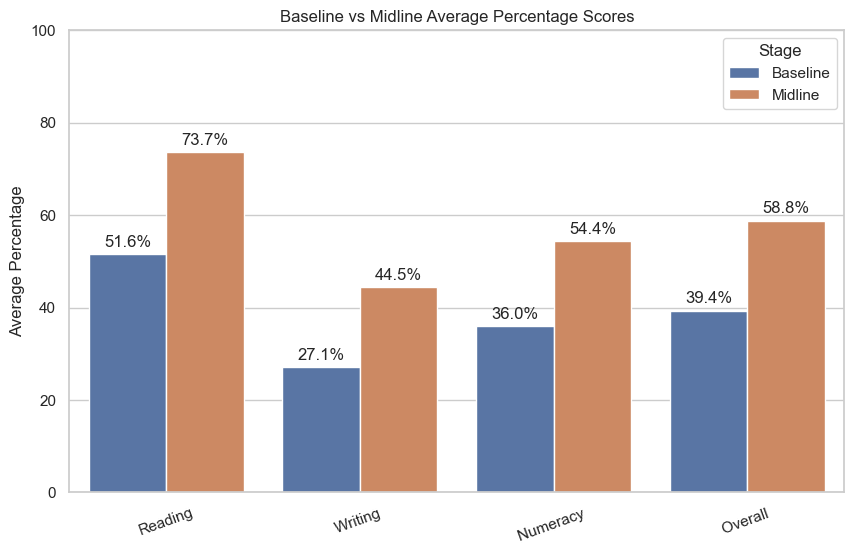

In [10]:
# =========================================================
# 8. OVERALL VISUALS
# =========================================================

# 8.1 Baseline vs Midline Average Scores

overall_compare_plot = overall_compare.reset_index().melt(
    id_vars='index',
    var_name='Stage',
    value_name='Average_Percentage'
)
overall_compare_plot.rename(columns={'index': 'Metric'}, inplace=True)

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=overall_compare_plot, x='Metric', y='Average_Percentage', hue='Stage')
add_pct_labels(ax, decimals=1)
plt.title("Baseline vs Midline Average Percentage Scores")
plt.ylabel("Average Percentage")
plt.xlabel("")
plt.ylim(0, 100)
plt.xticks(rotation=20)
plt.show()

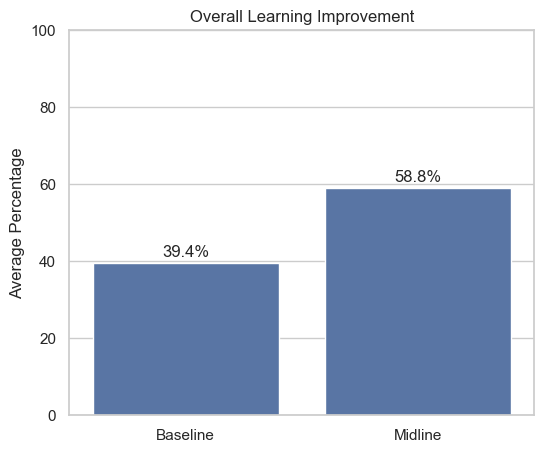

In [11]:
# 8.2 Overall Learning Improvement

overall_only = pd.DataFrame({
    'Stage': ['Baseline', 'Midline'],
    'Overall_Percentage': [
        baseline_df['Overall_%'].mean(),
        midline_df['Overall_%'].mean()
    ]
})

plt.figure(figsize=(6, 5))
ax = sns.barplot(data=overall_only, x='Stage', y='Overall_Percentage')
add_pct_labels(ax, decimals=1)
plt.title("Overall Learning Improvement")
plt.ylabel("Average Percentage")
plt.xlabel("")
plt.ylim(0, 100)
plt.show()


In [12]:
# =========================================================
# OVERALL LEARNING GAINS (PERCENTAGE) - TREATMENT vs CONTROL
# =========================================================

# Step 1: Filter only valid groups
baseline_group = baseline_df[baseline_df['Group'].isin(['Control', 'Treatment'])]
midline_group = midline_df[midline_df['Group'].isin(['Control', 'Treatment'])]

# Step 2: Calculate mean scores
baseline_mean = baseline_group.groupby('Group')['Overall_Score'].mean()
midline_mean = midline_group.groupby('Group')['Overall_Score'].mean()

# Step 3: Calculate improvement (convert to percentage)
improvement_pct = ((midline_mean - baseline_mean) / 80) * 100

# Step 4: Create final table
overall_gain_pct = pd.DataFrame({
    'Baseline_%': (baseline_mean / 80) * 100,
    'Midline_%': (midline_mean / 80) * 100,
    'Improvement_%': improvement_pct
}).round(2)

print("\nOverall Learning Gains (in %)")
print(overall_gain_pct)


Overall Learning Gains (in %)
           Baseline_%  Midline_%  Improvement_%
Group                                          
Control         42.32      56.45          14.13
Treatment       34.74      61.88          27.14


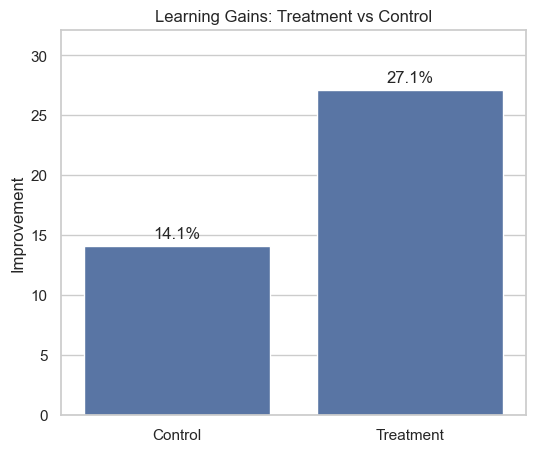

In [13]:
# =========================================================
# CHART: LEARNING GAINS IN %
# =========================================================

gain_plot = overall_gain_pct.reset_index()

plt.figure(figsize=(6, 5))
ax = sns.barplot(data=gain_plot, x='Group', y='Improvement_%')

# Add % labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3)

plt.title("Learning Gains: Treatment vs Control")
plt.ylabel("Improvement")
plt.xlabel("")
plt.ylim(0, gain_plot['Improvement_%'].max() + 5)
plt.show()

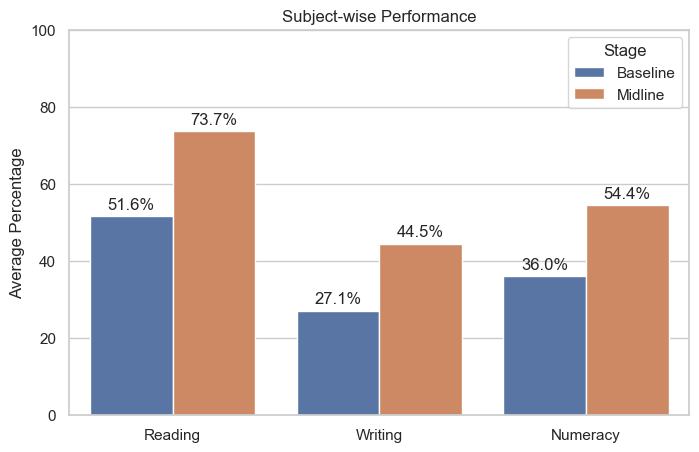

In [14]:
# 8.3 Subject-wise Performance


subject_plot = pd.DataFrame({
    'Subject': ['Reading', 'Writing', 'Numeracy'],
    'Baseline': [
        baseline_df['Reading_%'].mean(),
        baseline_df['Writing_%'].mean(),
        baseline_df['Numeracy_%'].mean()
    ],
    'Midline': [
        midline_df['Reading_%'].mean(),
        midline_df['Writing_%'].mean(),
        midline_df['Numeracy_%'].mean()
    ]
})

subject_plot_melted = subject_plot.melt(
    id_vars='Subject',
    var_name='Stage',
    value_name='Average_Percentage'
)

plt.figure(figsize=(8, 5))
ax = sns.barplot(data=subject_plot_melted, x='Subject', y='Average_Percentage', hue='Stage')
add_pct_labels(ax, decimals=1)
plt.title("Subject-wise Performance")
plt.ylabel("Average Percentage")
plt.xlabel("")
plt.ylim(0, 100)
plt.show()


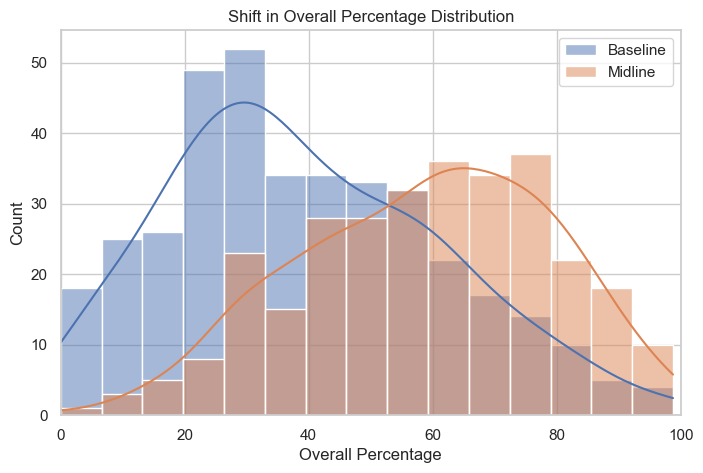

In [15]:
# 8.4 Shift in Overall Score Distribution


plt.figure(figsize=(8, 5))
sns.histplot(baseline_df['Overall_%'], kde=True, label='Baseline', bins=15)
sns.histplot(midline_df['Overall_%'], kde=True, label='Midline', bins=15)
plt.legend()
plt.title("Shift in Overall Percentage Distribution")
plt.xlabel("Overall Percentage")
plt.ylabel("Count")
plt.xlim(0, 100)
plt.show()

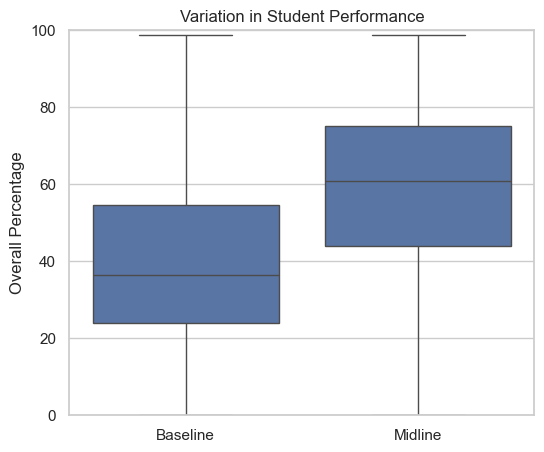

In [16]:
# 8.5 Variation in Student Performance


score_dist = pd.concat([
    baseline_df[['Overall_%']].assign(Stage='Baseline'),
    midline_df[['Overall_%']].assign(Stage='Midline')
], ignore_index=True)

plt.figure(figsize=(6, 5))
sns.boxplot(data=score_dist, x='Stage', y='Overall_%')
plt.title("Variation in Student Performance")
plt.xlabel("")
plt.ylabel("Overall Percentage")
plt.ylim(0, 100)
plt.show()

# =========================================================
# 9. GROUP-WISE ANALYSIS
# =========================================================

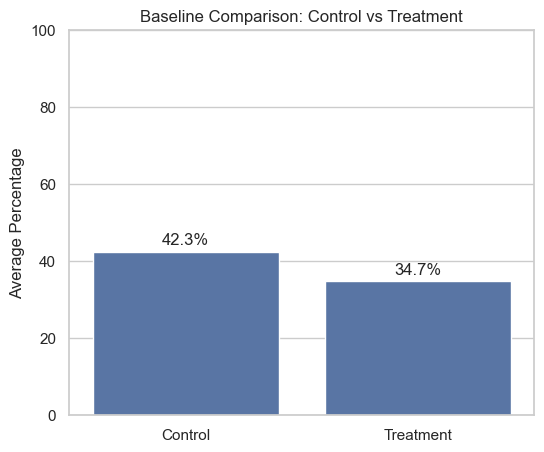

In [17]:
# 9.1 Baseline Comparison: Control vs Treatment

baseline_group_only = (
    baseline_df[baseline_df['Group'].isin(['Control', 'Treatment'])]
    .groupby('Group', as_index=False)['Overall_%']
    .mean()
)

plt.figure(figsize=(6, 5))
ax = sns.barplot(data=baseline_group_only, x='Group', y='Overall_%')
add_pct_labels(ax, decimals=1)
plt.title("Baseline Comparison: Control vs Treatment")
plt.ylabel("Average Percentage")
plt.xlabel("")
plt.ylim(0, 100)
plt.show()

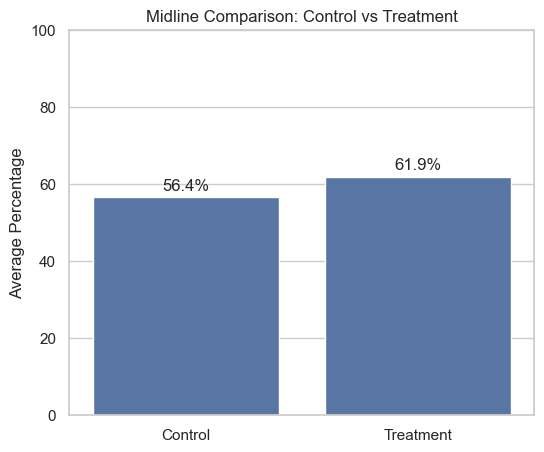

In [18]:
# 9.2 Midline Comparison: Control vs Treatment


midline_group_only = (
    midline_df[midline_df['Group'].isin(['Control', 'Treatment'])]
    .groupby('Group', as_index=False)['Overall_%']
    .mean()
)

plt.figure(figsize=(6, 5))
ax = sns.barplot(data=midline_group_only, x='Group', y='Overall_%')
add_pct_labels(ax, decimals=1)
plt.title("Midline Comparison: Control vs Treatment")
plt.ylabel("Average Percentage")
plt.xlabel("")
plt.ylim(0, 100)
plt.show()

In [19]:
# # 9.3 Group-wise Tercile Distribution (Counts)
# baseline_tercile_group = pd.crosstab(
#     baseline_df['Group'],
#     baseline_df['Tercile_Label']
# )

# midline_tercile_group = pd.crosstab(
#     midline_df['Group'],
#     midline_df['Tercile_Label']
# )

# desired_order = ['Below Basic', 'Basic', 'Proficient']

# baseline_tercile_group = baseline_tercile_group.reindex(
#     index=['Control', 'Treatment'],
#     columns=desired_order,
#     fill_value=0
# )

# midline_tercile_group = midline_tercile_group.reindex(
#     index=['Control', 'Treatment'],
#     columns=desired_order,
#     fill_value=0
# )

# baseline_tercile_group.plot(kind='bar', stacked=True, figsize=(8, 5))
# plt.title("Baseline Group-wise Performance Distribution")
# plt.ylabel("Number of Students")
# plt.xlabel("")
# plt.xticks(rotation=0)
# plt.show()

# midline_tercile_group.plot(kind='bar', stacked=True, figsize=(8, 5))
# plt.title("Midline Group-wise Performance Distribution")
# plt.ylabel("Number of Students")
# plt.xlabel("")
# plt.xticks(rotation=0)
# plt.show()


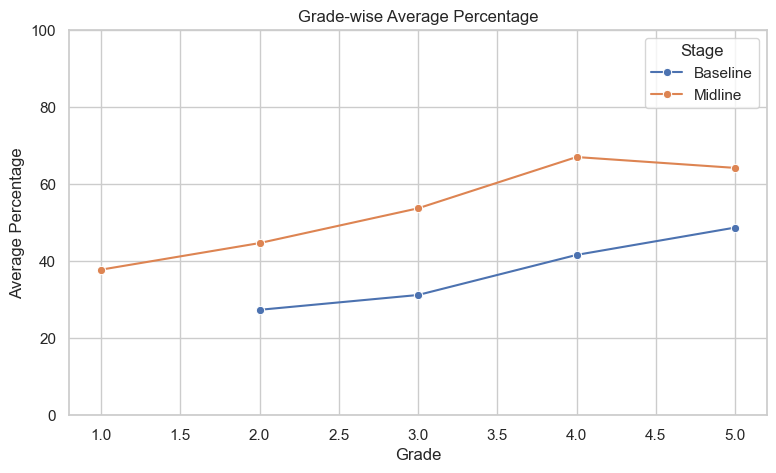

In [20]:
# =========================================================
# 10. GRADE-WISE ANALYSIS
# =========================================================

baseline_grade = baseline_df.groupby('Grade', as_index=False)['Overall_%'].mean()
baseline_grade['Stage'] = 'Baseline'

midline_grade = midline_df.groupby('Grade', as_index=False)['Overall_%'].mean()
midline_grade['Stage'] = 'Midline'

grade_plot = pd.concat([baseline_grade, midline_grade], ignore_index=True)
grade_plot = grade_plot[grade_plot['Grade'].notna()]

plt.figure(figsize=(9, 5))
ax = sns.lineplot(data=grade_plot, x='Grade', y='Overall_%', hue='Stage', marker='o')
plt.title("Grade-wise Average Percentage")
plt.ylabel("Average Percentage")
plt.xlabel("Grade")
plt.ylim(0, 100)
plt.show()



Baseline Gender Distribution
Gender_(M/F)
F    214
M    161
Name: count, dtype: int64

Midline Gender Distribution
Gender_(M/F)
F      178
M      120
L        1
NAN      1
Name: count, dtype: int64


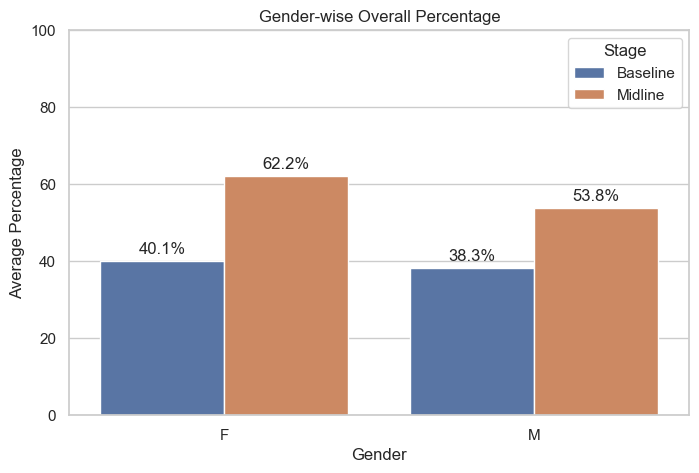

In [21]:
# =========================================================
# 11. GENDER-WISE ANALYSIS
# =========================================================

print("\nBaseline Gender Distribution")
print(baseline_df['Gender_(M/F)'].value_counts(dropna=False))

print("\nMidline Gender Distribution")
print(midline_df['Gender_(M/F)'].value_counts(dropna=False))


baseline_gender = (
    baseline_df[baseline_df['Gender_(M/F)'].isin(['M', 'F'])]
    .groupby('Gender_(M/F)', as_index=False)['Overall_%']
    .mean()
)
baseline_gender['Stage'] = 'Baseline'

midline_gender = (
    midline_df[midline_df['Gender_(M/F)'].isin(['M', 'F'])]
    .groupby('Gender_(M/F)', as_index=False)['Overall_%']
    .mean()
)
midline_gender['Stage'] = 'Midline'

gender_plot = pd.concat([baseline_gender, midline_gender], ignore_index=True)

plt.figure(figsize=(8, 5))
ax = sns.barplot(data=gender_plot, x='Gender_(M/F)', y='Overall_%', hue='Stage')
add_pct_labels(ax, decimals=1)
plt.title("Gender-wise Overall Percentage")
plt.xlabel("Gender")
plt.ylabel("Average Percentage")
plt.ylim(0, 100)
plt.show()


# ---------------------------------------------------------
# Overall Analysis student-grade wise
# ---------------------------------------------------------

In [23]:
# ---------------------------------------------------------
# SUBJECT-WISE IMPROVEMENT (%): TREATMENT vs CONTROL
# ---------------------------------------------------------

subject_gain = (
    pd.concat([
        baseline_ct.groupby('Group', as_index=False)[['Reading_%', 'Writing_%', 'Numeracy_%']].mean().assign(Stage='Baseline'),
        midline_ct.groupby('Group', as_index=False)[['Reading_%', 'Writing_%', 'Numeracy_%']].mean().assign(Stage='Midline')
    ], ignore_index=True)
)

# wide table
base_tbl = subject_gain[subject_gain['Stage'] == 'Baseline'].set_index('Group')
mid_tbl  = subject_gain[subject_gain['Stage'] == 'Midline'].set_index('Group')

improve_tbl = pd.DataFrame({
    'Group': ['Control', 'Treatment'],
    'Reading': [
        mid_tbl.loc['Control', 'Reading_%'] - base_tbl.loc['Control', 'Reading_%'],
        mid_tbl.loc['Treatment', 'Reading_%'] - base_tbl.loc['Treatment', 'Reading_%']
    ],
    'Writing': [
        mid_tbl.loc['Control', 'Writing_%'] - base_tbl.loc['Control', 'Writing_%'],
        mid_tbl.loc['Treatment', 'Writing_%'] - base_tbl.loc['Treatment', 'Writing_%']
    ],
    'Numeracy': [
        mid_tbl.loc['Control', 'Numeracy_%'] - base_tbl.loc['Control', 'Numeracy_%'],
        mid_tbl.loc['Treatment', 'Numeracy_%'] - base_tbl.loc['Treatment', 'Numeracy_%']
    ]
}).round(1)

improve_long = improve_tbl.melt(
    id_vars='Group',
    var_name='Subject',
    value_name='Improvement'
)

plt.figure(figsize=(8, 5))
ax = sns.barplot(
    data=improve_long,
    x='Subject',
    y='Improvement',
    hue='Group',
    palette={'Control': '#4d79ff', 'Treatment': '#f4a261'}
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3)

plt.title("Subject-wise Improvement: Treatment vs Control")
plt.ylabel("Improvemet")
plt.xlabel("")
plt.legend(title='')
plt.tight_layout()
plt.show()

print(improve_tbl)

NameError: name 'baseline_ct' is not defined

In [ ]:
# ---------------------------------------------------------
# 1. KEEP ONLY CONTROL / TREATMENT
# ---------------------------------------------------------

baseline_ct = baseline_df[baseline_df['Group'].isin(['Control', 'Treatment'])].copy()
midline_ct  = midline_df[midline_df['Group'].isin(['Control', 'Treatment'])].copy()

print("Baseline shape (Control/Treatment only):", baseline_ct.shape)
print("Midline shape (Control/Treatment only):", midline_ct.shape)

In [24]:
# ---------------------------------------------------------
# 2. STUDENT COUNTS
# ---------------------------------------------------------
print("\n================ STUDENT COUNTS ================\n")

baseline_counts_group = baseline_ct.groupby('Group').size().reset_index(name='Baseline_n')
midline_counts_group  = midline_ct.groupby('Group').size().reset_index(name='Midline_n')

print("Baseline counts by group")
print(baseline_counts_group)

print("\nMidline counts by group")
print(midline_counts_group)

baseline_counts_grade = (
    baseline_ct.groupby(['Group', 'Grade'])
    .size()
    .reset_index(name='Baseline_n')
    .sort_values(['Group', 'Grade'])
)

midline_counts_grade = (
    midline_ct.groupby(['Group', 'Grade'])
    .size()
    .reset_index(name='Midline_n')
    .sort_values(['Group', 'Grade'])
)

print("\nBaseline counts by group and grade")
print(baseline_counts_grade)

print("\nMidline counts by group and grade")
print(midline_counts_grade)

baseline_counts_school = (
    baseline_ct.groupby(['Group', 'School_Name', 'Grade'])
    .size()
    .reset_index(name='Baseline_n')
    .sort_values(['Group', 'School_Name', 'Grade'])
)

midline_counts_school = (
    midline_ct.groupby(['Group', 'School_Name', 'Grade'])
    .size()
    .reset_index(name='Midline_n')
    .sort_values(['Group', 'School_Name', 'Grade'])
)

print("\nBaseline counts by school")
print(baseline_counts_school)

print("\nMidline counts by school")
print(midline_counts_school)



================ STUDENT COUNTS ================



NameError: name 'baseline_ct' is not defined

In [ ]:
# ---------------------------------------------------------
# 3. GRADE-WISE AVERAGE SCORES (BASELINE + MIDLINE)
# ---------------------------------------------------------
baseline_grade_subject = (
    baseline_ct.groupby(['Group', 'Grade'], as_index=False)[
        ['Reading_%', 'Writing_%', 'Numeracy_%', 'Overall_%']
    ]
    .mean()
)
baseline_grade_subject['Stage'] = 'Baseline'

midline_grade_subject = (
    midline_ct.groupby(['Group', 'Grade'], as_index=False)[
        ['Reading_%', 'Writing_%', 'Numeracy_%', 'Overall_%']
    ]
    .mean()
)
midline_grade_subject['Stage'] = 'Midline'

grade_subject_all = pd.concat([baseline_grade_subject, midline_grade_subject], ignore_index=True)

grade_subject_long = grade_subject_all.melt(
    id_vars=['Group', 'Grade', 'Stage'],
    value_vars=['Reading_%', 'Writing_%', 'Numeracy_%', 'Overall_%'],
    var_name='Subject',
    value_name='Percentage'
)

grade_subject_long['Subject'] = grade_subject_long['Subject'].replace({
    'Reading_%': 'Reading',
    'Writing_%': 'Writing',
    'Numeracy_%': 'Numeracy',
    'Overall_%': 'Overall'
})

print("\nGrade-wise subject comparison table")
print(grade_subject_long.head(20))


In [ ]:
print(grade_subject_long[['Group', 'Grade', 'Stage', 'Subject', 'Percentage']].head(20))
print("\nUnique Grades:", grade_subject_long['Grade'].unique())
print("\nUnique Groups:", grade_subject_long['Group'].unique())

In [ ]:
# =========================================================
# GRADE-WISE BASELINE CHARTS ONLY
# =========================================================

baseline_plot = plot_df[
    (plot_df['Stage'] == 'Baseline') &
    (plot_df['Grade'].isin([2, 3, 4, 5]))
].copy()

for grade in sorted(baseline_plot['Grade'].dropna().unique()):
    temp = baseline_plot[baseline_plot['Grade'] == grade].copy()

    groups_present = sorted(temp['Group'].dropna().unique().tolist())
    if len(groups_present) < 2:
        print(f"Skipping Grade {int(grade)} Baseline: only {groups_present} present")
        continue

    plt.figure(figsize=(10, 5))
    ax = sns.barplot(
        data=temp,
        x='Subject',
        y='Percentage',
        hue='Group',
        palette={'Control': '#4d79ff', 'Treatment': '#f4a261'}
    )

    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f%%', padding=3)

    plt.title(f'Grade {int(grade)}: Control vs Treatment (Baseline)')
    plt.ylabel('Average Percentage')
    plt.xlabel('')
    plt.ylim(0, 100)
    plt.legend(title='')
    plt.tight_layout()
    plt.show()
    plt.close()

In [ ]:
# =========================================================
# GRADE-WISE MIDLINE CHARTS ONLY
# =========================================================

midline_plot = plot_df[
    (plot_df['Stage'] == 'Midline') &
    (plot_df['Grade'].isin([2, 3, 4, 5]))
].copy()

for grade in sorted(midline_plot['Grade'].dropna().unique()):
    temp = midline_plot[midline_plot['Grade'] == grade].copy()

    groups_present = sorted(temp['Group'].dropna().unique().tolist())
    if len(groups_present) < 2:
        print(f"Skipping Grade {int(grade)} Midline: only {groups_present} present")
        continue

    plt.figure(figsize=(10, 5))
    ax = sns.barplot(
        data=temp,
        x='Subject',
        y='Percentage',
        hue='Group',
        palette={'Control': '#4d79ff', 'Treatment': '#f4a261'}
    )

    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f%%', padding=3)

    plt.title(f'Grade {int(grade)}: Control vs Treatment (Midline)')
    plt.ylabel('Average Percentage')
    plt.xlabel('')
    plt.ylim(0, 100)
    plt.legend(title='')
    plt.tight_layout()
    plt.show()
    plt.close()

In [ ]:
# ---------------------------------------------------------
# 5. GRADE-WISE BASELINE vs MIDLINE
#    (one chart per grade, stage comparison)
# ---------------------------------------------------------
for grade in sorted(grade_subject_long['Grade'].dropna().unique()):
    temp = grade_subject_long[grade_subject_long['Grade'] == grade].copy()

    plt.figure(figsize=(11, 5))
    ax = sns.barplot(
        data=temp,
        x='Subject',
        y='Percentage',
        hue='Stage',
        palette=['#4d79ff', '#f4a261']   # Baseline, Midline
    )

    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f%%', padding=3)

    plt.title(f'Grade {int(grade)}: Baseline vs Midline')
    plt.ylabel('Average Percentage')
    plt.xlabel('')
    plt.ylim(0, 100)
    plt.legend(title='')
    plt.tight_layout()
    plt.show()


In [ ]:
# ---------------------------------------------------------
# 6. SCHOOL-WISE SUBJECT TABLES
# ---------------------------------------------------------

baseline_school_subject = (
    baseline_ct.groupby(['Group', 'School_Name', 'Grade'], as_index=False)[
        ['Reading_%', 'Writing_%', 'Numeracy_%', 'Overall_%']
    ]
    .mean()
)
baseline_school_subject['Stage'] = 'Baseline'

midline_school_subject = (
    midline_ct.groupby(['Group', 'School_Name', 'Grade'], as_index=False)[
        ['Reading_%', 'Writing_%', 'Numeracy_%', 'Overall_%']
    ]
    .mean()
)
midline_school_subject['Stage'] = 'Midline'

school_subject_all = pd.concat([baseline_school_subject, midline_school_subject], ignore_index=True)

school_subject_long = school_subject_all.melt(
    id_vars=['Group', 'School_Name', 'Grade', 'Stage'],
    value_vars=['Reading_%', 'Writing_%', 'Numeracy_%', 'Overall_%'],
    var_name='Subject',
    value_name='Percentage'
)

school_subject_long['Subject'] = school_subject_long['Subject'].replace({
    'Reading_%': 'Reading',
    'Writing_%': 'Writing',
    'Numeracy_%': 'Numeracy',
    'Overall_%': 'Overall'
})

school_subject_long['Grade'] = pd.to_numeric(school_subject_long['Grade'], errors='coerce')

print("School-wise subject table")
print(school_subject_long.head(20))

In [ ]:
# ---------------------------------------------------------
# 7. BASELINE SCHOOL-WISE COMPARISON BY GRADE
#    (separate subject panels) - FIXED
# ---------------------------------------------------------

baseline_school_plot = school_subject_long[
    (school_subject_long['Stage'] == 'Baseline') &
    (school_subject_long['Grade'].isin([2, 3, 4, 5])) &
    (school_subject_long['Group'].isin(['Control', 'Treatment']))
].copy()

baseline_school_plot['School_Name_Wrapped'] = baseline_school_plot['School_Name'].apply(
    lambda x: wrap_school_name(x, width=12)
)

for grade in sorted(baseline_school_plot['Grade'].dropna().unique()):
    temp = baseline_school_plot[baseline_school_plot['Grade'] == grade].copy()

    if temp.empty:
        continue

    g = sns.catplot(
        data=temp,
        kind='bar',
        x='School_Name_Wrapped',
        y='Percentage',
        hue='Group',
        hue_order=['Control', 'Treatment'],   # IMPORTANT
        palette={'Control': '#4d79ff', 'Treatment': '#f4a261'},  # IMPORTANT
        col='Subject',
        col_wrap=2,
        height=4.8,
        aspect=1.35,
        sharey=True
    )

    g.set_titles(f'Grade {int(grade)} - {{col_name}} (Baseline)')
    g.set_axis_labels('', 'Average Percentage')
    g.set_xticklabels(rotation=0, ha='center')

    for ax in g.axes.flatten():
        for c_idx, container in enumerate(ax.containers):
            for bar in container:
                height = bar.get_height()
                if pd.notna(height) and height > 0:
                    ax.text(
                        bar.get_x() + bar.get_width() / 2,
                        height + 1 + (c_idx * 0.8),
                        f'{height:.1f}%',
                        ha='center',
                        va='bottom',
                        fontsize=8
                    )
        ax.set_ylim(0, 100)

    if g._legend is not None:
        g._legend.set_title('')
        g._legend.set_bbox_to_anchor((1.02, 0.95))

    plt.tight_layout()
    plt.show()

In [ ]:
# ---------------------------------------------------------
# 8. MIDLINE SCHOOL-WISE COMPARISON BY GRADE
#    (separate subject panels) - FIXED
# ---------------------------------------------------------

midline_school_plot = school_subject_long[
    (school_subject_long['Stage'] == 'Midline') &
    (school_subject_long['Grade'].isin([2, 3, 4, 5])) &
    (school_subject_long['Group'].isin(['Control', 'Treatment']))
].copy()

midline_school_plot['School_Name_Wrapped'] = midline_school_plot['School_Name'].apply(
    lambda x: wrap_school_name(x, width=12)
)

for grade in sorted(midline_school_plot['Grade'].dropna().unique()):
    temp = midline_school_plot[midline_school_plot['Grade'] == grade].copy()

    if temp.empty:
        continue

    g = sns.catplot(
        data=temp,
        kind='bar',
        x='School_Name_Wrapped',
        y='Percentage',
        hue='Group',
        hue_order=['Control', 'Treatment'],   # IMPORTANT
        palette={'Control': '#4d79ff', 'Treatment': '#f4a261'},  # IMPORTANT
        col='Subject',
        col_wrap=2,
        height=4.8,
        aspect=1.35,
        sharey=True
    )

    g.set_titles(f'Grade {int(grade)} - {{col_name}} (Midline)')
    g.set_axis_labels('', 'Average Percentage')
    g.set_xticklabels(rotation=0, ha='center')

    for ax in g.axes.flatten():
        for c_idx, container in enumerate(ax.containers):
            for bar in container:
                height = bar.get_height()
                if pd.notna(height) and height > 0:
                    ax.text(
                        bar.get_x() + bar.get_width() / 2,
                        height + 1 + (c_idx * 0.8),   # stagger label positions slightly
                        f'{height:.1f}%',
                        ha='center',
                        va='bottom',
                        fontsize=8
                    )
        ax.set_ylim(0, 100)

    # move legend nicely
    if g._legend is not None:
        g._legend.set_title('')
        g._legend.set_bbox_to_anchor((1.02, 0.95))

    plt.tight_layout()
    plt.show()

In [ ]:
# ---------------------------------------------------------
# 9. SCHOOL-WISE SUBJECT PERFORMANCE
#    (one chart per grade + stage, all subjects together) - FINAL CLEAN
# ---------------------------------------------------------

school_perf_plot = school_subject_long[
    (school_subject_long['Grade'].isin([2, 3, 4, 5])) &
    (school_subject_long['Group'].isin(['Control', 'Treatment']))
].copy()

school_perf_plot['School_Name_Wrapped'] = school_perf_plot['School_Name'].apply(
    lambda x: wrap_school_name(x, width=12)
)

for grade in sorted(school_perf_plot['Grade'].dropna().unique()):
    for stage in ['Baseline', 'Midline']:
        temp = school_perf_plot[
            (school_perf_plot['Grade'] == grade) &
            (school_perf_plot['Stage'] == stage)
        ].copy()

        if temp.empty:
            continue

        plt.figure(figsize=(20, 9))
        ax = sns.barplot(
            data=temp,
            x='School_Name_Wrapped',
            y='Percentage',
            hue='Subject',
            hue_order=['Reading', 'Writing', 'Numeracy', 'Overall'],
            palette={
                'Reading': '#4d79ff',
                'Writing': '#ff6f91',
                'Numeracy': '#66bb6a',
                'Overall': '#f4a261'
            }
        )

        # smarter labels
        for c_idx, container in enumerate(ax.containers):
            for bar in container:
                height = bar.get_height()

                if pd.isna(height) or height <= 0:
                    continue

                x = bar.get_x() + bar.get_width() / 2

                # bigger stagger so same-height bars don't collide
                extra_offset = c_idx * 1.8

                # if bar is very small, push label above more
                if height < 8:
                    y = height + 2.5 + extra_offset
                    fs = 9
                else:
                    y = height + 1.2 + extra_offset
                    fs = 9

                ax.text(
                    x,
                    y,
                    f'{height:.1f}%',
                    ha='center',
                    va='bottom',
                    fontsize=13,
                    color='black',
                    fontweight='bold'
                )

        plt.title(
            f'Grade {int(grade)} - {stage}: School-wise Subject Performance',
            fontsize=17,
            fontweight='bold'
        )
        plt.ylabel('Average Percentage', fontsize=14, fontweight='bold')
        plt.xlabel('')
        plt.ylim(0, 110)   # extra headroom for staggered labels

        # school names darker and larger
        plt.xticks(
            rotation=0,
            ha='center',
            fontsize=15,
            color='black',
            fontweight='bold'
        )

        plt.yticks(fontsize=11, color='black')
        ax.tick_params(axis='y', colors='black')
        ax.tick_params(axis='x', colors='black')

        # legend inside but neat
        plt.legend(
            title='',
            loc='upper right',
            frameon=True,
            fontsize=12
        )

        plt.tight_layout()
        plt.show()

In [ ]:
# ---------------------------------------------------------
# 10. SCHOOL-WISE SUMMARY TABLES WITH STUDENT COUNTS
# ---------------------------------------------------------

baseline_school_summary = (
    baseline_ct.groupby(['Group', 'School_Name', 'Grade'], as_index=False)
    .agg(
        Students_Tested=('Student_Name', 'count'),
        Reading_Percentage=('Reading_%', 'mean'),
        Writing_Percentage=('Writing_%', 'mean'),
        Numeracy_Percentage=('Numeracy_%', 'mean'),
        Overall_Percentage=('Overall_%', 'mean')
    )
    .sort_values(['Group', 'Grade', 'School_Name'])
)

midline_school_summary = (
    midline_ct.groupby(['Group', 'School_Name', 'Grade'], as_index=False)
    .agg(
        Students_Tested=('Student_Name', 'count'),
        Reading_Percentage=('Reading_%', 'mean'),
        Writing_Percentage=('Writing_%', 'mean'),
        Numeracy_Percentage=('Numeracy_%', 'mean'),
        Overall_Percentage=('Overall_%', 'mean')
    )
    .sort_values(['Group', 'Grade', 'School_Name'])
)

print("\n================ BASELINE SCHOOL SUMMARY ================\n")
print(baseline_school_summary.round(1))

print("\n================ MIDLINE SCHOOL SUMMARY ================\n")
print(midline_school_summary.round(1))

In [ ]:
# ---------------------------------------------------------
# SCHOOL-WISE SINGLE-SUBJECT PERFORMANCE
# one chart per grade + stage + subject
# ---------------------------------------------------------

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import textwrap

def wrap_school_name(name, width=12):
    if pd.isna(name):
        return name
    return "\n".join(textwrap.wrap(str(name), width=width))

school_single_plot = school_subject_long[
    (school_subject_long['Grade'].isin([2, 3, 4, 5])) &
    (school_subject_long['Group'].isin(['Control', 'Treatment']))
].copy()

school_single_plot['School_Name_Wrapped'] = school_single_plot['School_Name'].apply(
    lambda x: wrap_school_name(x, width=12)
)

for grade in sorted(school_single_plot['Grade'].dropna().unique()):
    for stage in ['Baseline', 'Midline']:
        for subject in ['Reading', 'Writing', 'Numeracy', 'Overall']:
            temp = school_single_plot[
                (school_single_plot['Grade'] == grade) &
                (school_single_plot['Stage'] == stage) &
                (school_single_plot['Subject'] == subject)
            ].copy()

            if temp.empty:
                continue

            # sort so chart looks cleaner
            temp = temp.sort_values(by=['Group', 'Percentage']).copy()

            plt.figure(figsize=(12, 6))
            ax = sns.barplot(
                data=temp,
                x='School_Name_Wrapped',
                y='Percentage',
                hue='Group',
                hue_order=['Control', 'Treatment'],
                palette={'Control': '#f39c12', 'Treatment': '#4d79ff'}
            )

            # labels on bars
            for container in ax.containers:
                for bar in container:
                    height = bar.get_height()
                    if pd.notna(height) and height > 0:
                        if height >= 10:
                            ax.text(
                                bar.get_x() + bar.get_width()/2,
                                height - 4,
                                f'{height:.0f}%',
                                ha='center',
                                va='center',
                                fontsize=14,
                                color='black',
                                fontweight='bold'
                            )
                        else:
                            ax.text(
                                bar.get_x() + bar.get_width()/2,
                                height + 2,
                                f'{height:.0f}%',
                                ha='center',
                                va='bottom',
                                fontsize=14,
                                color='black',
                                fontweight='bold'
                            )

            plt.title(f'Grade {int(grade)} {subject} Scores by School ({stage})',
                      fontsize=17, fontweight='bold')
            plt.ylabel('Average Percentage', fontsize=15, fontweight='bold')
            plt.xlabel('')
            plt.ylim(0, 100)

            plt.xticks(
                rotation=0,
                ha='center',
                fontsize=14,
                color='black',
                fontweight='bold'
            )

            plt.yticks(
                ticks=[0, 25, 50, 75, 100],
                labels=['0%', '25%', '50%', '75%', '100%'],
                fontsize=11,
                color='black'
            )

            plt.legend(
                title='',
                loc='upper center',
                bbox_to_anchor=(0.5, 0.9),
                ncol=2,
                frameon=False,
                fontsize=11
            )

            plt.tight_layout()
            plt.show()

In [ ]:
# ---------------------------------------------------------
# SCHOOL-WISE SINGLE-SUBJECT PERFORMANCE
# ALL GRADES COMBINED | ONE SUBJECT AT A TIME
# ---------------------------------------------------------

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import textwrap

def wrap_school_name(name, width=12):
    if pd.isna(name):
        return name
    return "\n".join(textwrap.wrap(str(name), width=width))

# use already-created school summary
school_single_plot = school_subject_long[
    (school_subject_long['Grade'].isin([2, 3, 4, 5])) &
    (school_subject_long['Group'].isin(['Control', 'Treatment']))
].copy()

# combine all grades at school level
school_single_plot = (
    school_single_plot
    .groupby(['Group', 'School_Name', 'Stage', 'Subject'], as_index=False)['Percentage']
    .mean()
)

school_single_plot['School_Name_Wrapped'] = school_single_plot['School_Name'].apply(
    lambda x: wrap_school_name(x, width=12)
)

# choose only important subjects
subjects_to_plot = ['Reading', 'Numeracy', 'Overall']   # add 'Writing' only if needed

for stage in ['Baseline', 'Midline']:
    for subject in subjects_to_plot:
        temp = school_single_plot[
            (school_single_plot['Stage'] == stage) &
            (school_single_plot['Subject'] == subject)
        ].copy()

        if temp.empty:
            continue

        # sort for cleaner view
        temp = temp.sort_values(by=['Group', 'Percentage']).copy()

        plt.figure(figsize=(13, 6))
        ax = sns.barplot(
            data=temp,
            x='School_Name_Wrapped',
            y='Percentage',
            hue='Group',
            hue_order=['Control', 'Treatment'],
            palette={'Control': '#f39c12', 'Treatment': '#4d79ff'}
        )

        # value labels
        for container in ax.containers:
            for bar in container:
                h = bar.get_height()
                if pd.notna(h) and h > 0:
                    if h >= 12:
                        ax.text(
                            bar.get_x() + bar.get_width()/2,
                            h - 4,
                            f'{h:.0f}%',
                            ha='center',
                            va='center',
                            fontsize=14,
                            color='black',
                            fontweight='bold'
                        )
                    else:
                        ax.text(
                            bar.get_x() + bar.get_width()/2,
                            h + 2,
                            f'{h:.0f}%',
                            ha='center',
                            va='bottom',
                            fontsize=14,
                            color='black',
                            fontweight='bold'
                        )

        plt.title(f'{subject} Scores by School ({stage})', fontsize=18, fontweight='bold')
        plt.ylabel('Average Percentage', fontsize=13, fontweight='bold')
        plt.xlabel('')
        plt.ylim(0, 100)

        plt.xticks(
            rotation=0,
            ha='center',
            fontsize=14,
            color='black',
            fontweight='bold'
        )

        plt.yticks(
            ticks=[0, 25, 50, 75, 100],
            labels=['0%', '25%', '50%', '75%', '100%'],
            fontsize=14,
            color='black'
        )

        plt.legend(
            title='',
            loc='upper center',
            bbox_to_anchor=(0.5, 0.90),
            ncol=2,
            frameon=False,
            fontsize=14
        )

        plt.tight_layout()
        plt.show()

In [ ]:
# ---------------------------------------------------------
# FIXED PERFORMANCE LEVELS
# Below Basic: 0–33
# Basic: 34–66
# Proficient: 67–100
# ---------------------------------------------------------

def assign_performance_level(score):
    if pd.isna(score):
        return np.nan
    elif score <= 33:
        return 'Below Basic'
    elif score <= 66:
        return 'Basic'
    else:
        return 'Proficient'

# apply fixed performance levels
baseline_df['Performance_Level'] = baseline_df['Overall_%'].apply(assign_performance_level)
midline_df['Performance_Level'] = midline_df['Overall_%'].apply(assign_performance_level)

# keep order
level_order = ['Below Basic', 'Basic', 'Proficient']

baseline_df['Performance_Level'] = pd.Categorical(
    baseline_df['Performance_Level'],
    categories=level_order,
    ordered=True
)

midline_df['Performance_Level'] = pd.Categorical(
    midline_df['Performance_Level'],
    categories=level_order,
    ordered=True
)

In [ ]:
# ---------------------------------------------------------
# PERFORMANCE LEVELS BY GROUP - BASELINE
# ---------------------------------------------------------

baseline_perf = pd.crosstab(
    baseline_df['Group'],
    baseline_df['Performance_Level'],
    normalize='index'
).mul(100)

baseline_perf = baseline_perf.reindex(
    index=['Control', 'Treatment'],
    columns=level_order
).round(1)

baseline_perf_long = baseline_perf.reset_index().melt(
    id_vars='Group',
    var_name='Performance_Level',
    value_name='Percentage'
)

plt.figure(figsize=(8, 5))
ax = sns.barplot(
    data=baseline_perf_long,
    x='Group',
    y='Percentage',
    hue='Performance_Level',
    hue_order=level_order,
    palette={
        'Below Basic': '#ff6f91',
        'Basic': '#4d79ff',
        'Proficient': '#66bb6a'
    }
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3)

plt.title("Performance Levels by Group (Baseline)")
plt.ylabel("Percentage")
plt.xlabel("")
plt.ylim(0, 100)
plt.legend(title='')
plt.tight_layout()
plt.show()

print(baseline_perf)

In [ ]:
# ---------------------------------------------------------
# PERFORMANCE LEVELS BY GROUP - MIDLINE
# ---------------------------------------------------------

midline_perf = pd.crosstab(
    midline_df['Group'],
    midline_df['Performance_Level'],
    normalize='index'
).mul(100)

midline_perf = midline_perf.reindex(
    index=['Control', 'Treatment'],
    columns=level_order
).round(1)

midline_perf_long = midline_perf.reset_index().melt(
    id_vars='Group',
    var_name='Performance_Level',
    value_name='Percentage'
)

plt.figure(figsize=(8, 5))
ax = sns.barplot(
    data=midline_perf_long,
    x='Group',
    y='Percentage',
    hue='Performance_Level',
    hue_order=level_order,
    palette={
        'Below Basic': '#ff6f91',
        'Basic': '#4d79ff',
        'Proficient': '#66bb6a'
    }
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3)

plt.title("Performance Levels by Group (Midline)")
plt.ylabel("Percentage")
plt.xlabel("")
plt.ylim(0, 100)
plt.legend(title='')
plt.tight_layout()
plt.show()

print(midline_perf)

In [ ]:
# ---------------------------------------------------------
# TOP IMPROVERS (Matched Students)
# ---------------------------------------------------------

# 1. Create improvement column
impact_df['Improvement_%'] = impact_df['Overall_%_mid'] - impact_df['Overall_%_base']

# 2. Select useful columns
top_improvers = (
    impact_df[
        [
            'Student_Name_base',
            'School_Name_base',
            'Grade_base',
            'Group_base',
            'Overall_%_base',
            'Overall_%_mid',
            'Improvement_%'
        ]
    ]
    .sort_values(by='Improvement_%', ascending=False)
    .head(10)
    .reset_index(drop=True)
)

# 3. Rename columns for clean output
top_improvers = top_improvers.rename(columns={
    'Student_Name_base': 'Student_Name',
    'School_Name_base': 'School_Name',
    'Grade_base': 'Grade',
    'Group_base': 'Group',
    'Overall_%_base': 'Baseline_%',
    'Overall_%_mid': 'Midline_%',
    'Improvement_%': 'Improvement_%'
})

# 4. Round values
top_improvers[['Baseline_%', 'Midline_%', 'Improvement_%']] = (
    top_improvers[['Baseline_%', 'Midline_%', 'Improvement_%']].round(1)
)

print(top_improvers)

In [ ]:
# ---------------------------------------------------------
# EXPORT SCHOOL SUMMARY TABLES TO EXCEL
# ---------------------------------------------------------

output_path = r"C:\Users\Avikansh\Downloads\2026_Analysis\school_wise_summary.xlsx"

with pd.ExcelWriter(output_path, engine='openpyxl') as writer:
    baseline_school_summary.round(1).to_excel(writer, sheet_name='Baseline_School_Summary', index=False)
    midline_school_summary.round(1).to_excel(writer, sheet_name='Midline_School_Summary', index=False)

print(f"School-wise summary exported to:\n{output_path}")

# Independent T-Test

Compares means of two groups:

Baseline vs Midline

In [ ]:
from scipy.stats import ttest_ind

baseline_scores = baseline_df['Overall_%'].dropna()
midline_scores = midline_df['Overall_%'].dropna()

t_stat, p_value = ttest_ind(midline_scores, baseline_scores, equal_var=False)

print(t_stat, p_value)

print("T-stat:", round(t_stat, 3))

if p_value < 0.001:
    print("P-value: < 0.001")
else:
    print("P-value:", round(p_value, 4))

**T-stat (11.998) → very large difference between means**
**p-value (<0.001) → extremely unlikely due to chance**

**The improvement from baseline to midline is statistically significant and not due to random variation.**

### This test confirms strong improvement at the population level, but causality is better validated through matched analysis.

### There is very strong evidence against the null hypothesis, indicating that the difference between baseline and midline is statistically significant and unlikely due to chance.

In [ ]:
midline_df['Grade'] = pd.to_numeric(midline_df['Grade'], errors='coerce')

for g in [2,3,4,5]:
    print(g, len(midline_df[midline_df['Grade']==g]))

# One-Way ANOVA Test 

In [ ]:
from scipy.stats import f_oneway

groups = [
    midline_df[midline_df['Grade'] == 2]['Overall_%'].dropna(),
    midline_df[midline_df['Grade'] == 3]['Overall_%'].dropna(),
    midline_df[midline_df['Grade'] == 4]['Overall_%'].dropna(),
    midline_df[midline_df['Grade'] == 5]['Overall_%'].dropna()
]

f_stat, p_value = f_oneway(*groups)

print("F-stat:", round(f_stat, 3))
print("P-value:", round(p_value, 4))

## The ANOVA test shows that performance differs significantly across groups, but further analysis would be needed to identify exactly which groups differ.

# Chi-Square Test 

In [ ]:
from scipy.stats import chi2_contingency
import pandas as pd

contingency = pd.crosstab(
    midline_df['Group'],          # Control / Treatment
    midline_df['Tercile_Label']   # Below Basic / Basic / Proficient
)

chi2, p, dof, exp = chi2_contingency(contingency)

print("Chi-square:", round(chi2, 3))

if p < 0.001:
    print("P-value: < 0.001")
else:
    print("P-value:", round(p, 4))

Chi² = 0.21, p = 0.9005

What this test does

Checks:

“Are two categorical variables related?”

Example:

Gender vs Performance level
Baseline vs Midline distribution
What your result means
p = 0.9005 (very high)
👉 Means:

✔ No significant relationship
✔ Distribution is basically SAME

Interpretation:

👉 If you tested Gender vs Tercile:

“Gender does not significantly influence performance distribution.”

⚠️ Important insight

This is actually a good finding

👉 It means:

Program is gender neutral
No bias

# Correlation Test

Reading vs Numeracy
Writing vs Overall

In [ ]:
from scipy.stats import pearsonr

# Clean data
temp = midline_df[['Reading_%', 'Writing_%', 'Numeracy_%']].dropna()

# Reading vs Writing
r_rw, p_rw = pearsonr(temp['Reading_%'], temp['Writing_%'])

# Reading vs Numeracy
r_rn, p_rn = pearsonr(temp['Reading_%'], temp['Numeracy_%'])

# Writing vs Numeracy
r_wn, p_wn = pearsonr(temp['Writing_%'], temp['Numeracy_%'])

print("Reading vs Writing:", round(r_rw, 3), "| p:", p_rw)
print("Reading vs Numeracy:", round(r_rn, 3), "| p:", p_rn)
print("Writing vs Numeracy:", round(r_wn, 3), "| p:", p_wn)

# T-Test for control and Intervention

In [ ]:
from scipy.stats import ttest_ind

ctrl = midline_df[midline_df['Group']=='Control']['Overall_%'].dropna()
trt  = midline_df[midline_df['Group']=='Treatment']['Overall_%'].dropna()

t_stat, p = ttest_ind(trt, ctrl, equal_var=False)
print(t_stat, p)

print("T-stat:", round(t_stat, 3))
print("P-value:", round(p_value, 4))

# Chi-Square (Distribution: Control vs Treatment)

In [ ]:
from scipy.stats import chi2_contingency
import pandas as pd

ct = pd.crosstab(
    midline_df['Group'],
    midline_df['Tercile_Label']
)

chi2, p, dof, exp = chi2_contingency(ct)
print(chi2, p)

print("T-chi2:", round(chi2, 3))
print("P:", round(p, 4))

In [ ]:


# -----------------------------
# Create merge ID
# -----------------------------
for d in [baseline_df, midline_df]:
    d['Student_Name'] = d['Student_Name'].astype(str).str.strip().str.lower()
    d['School_Name'] = d['School_Name'].astype(str).str.strip().str.lower()
    d['Grade'] = d['Grade'].astype(str).str.strip()

    d['id'] = (
        d['Student_Name'] + "_" +
        d['School_Name'] + "_" +
        d['Grade']
    )

# -----------------------------
# Remove duplicates before merge
# -----------------------------
baseline_match = baseline_df.drop_duplicates(subset='id').copy()
midline_match = midline_df.drop_duplicates(subset='id').copy()

print("\nUnique baseline IDs:", baseline_match['id'].nunique())
print("Unique midline IDs:", midline_match['id'].nunique())

# -----------------------------
# Merge matched children
# -----------------------------
impact_df = pd.merge(
    baseline_match,
    midline_match,
    on='id',
    suffixes=('_base', '_mid')
)

print("Matched children:", impact_df.shape[0])

# -----------------------------
# Recalculate overall scores
# -----------------------------
impact_df['Overall_Score_base'] = (
    impact_df['Reading_Calculated_base'] +
    impact_df['Writing_Calculated_base'] +
    impact_df['Numeracy_Calculated_base']
)

impact_df['Overall_Score_mid'] = (
    impact_df['Reading_Calculated_mid'] +
    impact_df['Writing_Calculated_mid'] +
    impact_df['Numeracy_Calculated_mid']
)

# -----------------------------
# Convert to percentages
# Reading = 27
# Writing = 17
# Numeracy = 36
# Overall = 80
# -----------------------------
impact_df['Reading_%_base'] = (impact_df['Reading_Calculated_base'] / 27) * 100
impact_df['Reading_%_mid'] = (impact_df['Reading_Calculated_mid'] / 27) * 100

impact_df['Writing_%_base'] = (impact_df['Writing_Calculated_base'] / 17) * 100
impact_df['Writing_%_mid'] = (impact_df['Writing_Calculated_mid'] / 17) * 100

impact_df['Numeracy_%_base'] = (impact_df['Numeracy_Calculated_base'] / 36) * 100
impact_df['Numeracy_%_mid'] = (impact_df['Numeracy_Calculated_mid'] / 36) * 100

impact_df['Overall_%_base'] = (impact_df['Overall_Score_base'] / 80) * 100
impact_df['Overall_%_mid'] = (impact_df['Overall_Score_mid'] / 80) * 100

# -----------------------------
# Matched summary table
# -----------------------------
matched_summary = pd.DataFrame({
    'Baseline': [
        impact_df['Reading_%_base'].mean(),
        impact_df['Writing_%_base'].mean(),
        impact_df['Numeracy_%_base'].mean(),
        impact_df['Overall_%_base'].mean()
    ],
    'Midline': [
        impact_df['Reading_%_mid'].mean(),
        impact_df['Writing_%_mid'].mean(),
        impact_df['Numeracy_%_mid'].mean(),
        impact_df['Overall_%_mid'].mean()
    ]
}, index=['Reading', 'Writing', 'Numeracy', 'Overall']).round(2)

print("\nMatched Students Summary (%)")
print(matched_summary.round(1).astype(str) + '%')

# -----------------------------
# Group-wise matched summary
# -----------------------------
impact_group_pct = impact_df.groupby('Group_base')[
    ['Reading_%_base', 'Reading_%_mid',
     'Writing_%_base', 'Writing_%_mid',
     'Numeracy_%_base', 'Numeracy_%_mid',
     'Overall_%_base', 'Overall_%_mid']
].mean().round(2)

print("\nGroup-wise Matched Summary (%)")
print(impact_group_pct.round(1).astype(str) + '%')

<!-- Section 3: Impact Analysis Deep Dive (61 matched students) -->

# Marks Analysis

In [ ]:
# baseline_df.columns.tolist()

In [ ]:
reading_cols = [
    'Hindi_Reading_1', 'Hindi_Reading_2', 'Hindi_Reading_3',
    'Hindi_Reading_4', 'Hindi_Reading_5', 'Hindi_Reading_6',
    'Hindi_Reading_7'
]

writing_cols = [
    'Hindi_Writing_1', 'Hindi_Writing_2',
    'Hindi_Writing_3', 'Hindi_Writing_4'
]

numeracy_cols = [
    'Numeracy_Q1', 'Numeracy_Q2', 'Numeracy_Q3', 'Numeracy_Q4',
    'Numeracy_Q5', 'Numeracy_Q6', 'Numeracy_Q7', 'Numeracy_Q8',
    'Numeracy_Q9', 'Numeracy_Q10', 'Numeracy_Q11'
]

all_question_cols = reading_cols + writing_cols + numeracy_cols

print(all_question_cols)
print([col for col in all_question_cols if col not in baseline_df.columns])
print([col for col in all_question_cols if col not in midline_df.columns])


In [ ]:
baseline_df[all_question_cols] = baseline_df[all_question_cols].apply(pd.to_numeric, errors='coerce')
midline_df[all_question_cols] = midline_df[all_question_cols].apply(pd.to_numeric, errors='coerce')

baseline_df['Total_Marks_80'] = baseline_df[all_question_cols].sum(axis=1)
baseline_df['Percentage_80'] = (baseline_df['Total_Marks_80'] / 80) * 100

midline_df['Total_Marks_80'] = midline_df[all_question_cols].sum(axis=1)
midline_df['Percentage_80'] = (midline_df['Total_Marks_80'] / 80) * 100

In [ ]:
baseline_grade_pct = baseline_df.groupby('Grade', as_index=False)['Percentage_80'].mean().round(2)
baseline_grade_pct['Stage'] = 'Baseline'

midline_grade_pct = midline_df.groupby('Grade', as_index=False)['Percentage_80'].mean().round(2)
midline_grade_pct['Stage'] = 'Midline'

grade_compare_pct = pd.concat([baseline_grade_pct, midline_grade_pct], ignore_index=True)
print(grade_compare_pct)

In [ ]:
# Clean Grade column in both datasets
for d in [baseline_df, midline_df]:
    d['Grade'] = d['Grade'].astype(str).str.strip()

    # remove common junk values
    d['Grade'] = d['Grade'].replace({
        'nan': np.nan,
        'NaN': np.nan,
        'None': np.nan,
        '': np.nan,
        '0': np.nan,
        '0.0': np.nan
    })

    # convert numeric-like grades properly
    d['Grade'] = pd.to_numeric(d['Grade'], errors='coerce')

    # keep only valid grades you want
    d.loc[~d['Grade'].isin([1, 2, 3, 4, 5]), 'Grade'] = np.nan

    # convert to integer then string for clean labels
    d['Grade'] = d['Grade'].astype('Int64').astype(str)

    # remove "<NA>" text created by astype(str)
    d['Grade'] = d['Grade'].replace('<NA>', np.nan)

In [ ]:
question_max_marks = {
    # Reading
    'Hindi_Reading_1': 5,
    'Hindi_Reading_2': 4,
    'Hindi_Reading_3': 5,
    'Hindi_Reading_4': 4,
    'Hindi_Reading_5': 3,
    'Hindi_Reading_6': 3,
    'Hindi_Reading_7': 3,

    # Writing
    'Hindi_Writing_1': 6,
    'Hindi_Writing_2': 3,
    'Hindi_Writing_3': 4,
    'Hindi_Writing_4': 4,

    # Numeracy (FIXED)
    'Numeracy_Q1': 5,
    'Numeracy_Q2': 4,
    'Numeracy_Q3': 3,
    'Numeracy_Q4': 3,
    'Numeracy_Q5': 3,
    'Numeracy_Q6': 3,
    'Numeracy_Q7': 3,
    'Numeracy_Q8': 3,
    'Numeracy_Q9': 4,
    'Numeracy_Q10': 2,
    'Numeracy_Q11': 3
}

In [ ]:
def plot_question_chart(df, q_col, q_max, title, stage_label):
    temp = df.copy()

    temp['Grade'] = pd.to_numeric(temp['Grade'], errors='coerce')

    temp = temp[
        temp['Group'].isin(['Treatment', 'Control']) &
        temp['Grade'].isin([2, 3, 4, 5])
    ].copy()

    temp[q_col] = pd.to_numeric(temp[q_col], errors='coerce')

    chart_df = (
        temp.groupby(['Group', 'Grade'], as_index=False)[q_col]
        .mean()
    )

    chart_df['Percentage'] = (chart_df[q_col] / q_max) * 100
    chart_df['Percentage'] = chart_df['Percentage'].clip(lower=0, upper=100)

    # Keep order
    group_order = ['Treatment', 'Control']
    grade_order = [2, 3, 4, 5]

    chart_df['Group'] = pd.Categorical(chart_df['Group'], categories=group_order, ordered=True)
    chart_df['Grade'] = pd.Categorical(chart_df['Grade'], categories=grade_order, ordered=True)
    chart_df = chart_df.sort_values(['Group', 'Grade']).reset_index(drop=True)

    # X positions
    x = list(range(len(chart_df)))

    colors = ['#4a80e0'] * 4 + ['#f39c12'] * 4

    plt.figure(figsize=(10, 5))
    ax = plt.gca()

    bars = ax.bar(x, chart_df['Percentage'], color=colors[:len(chart_df)])

    # value labels inside / above bars
    for i, v in enumerate(chart_df['Percentage']):
        if v >= 12:
            ax.text(i, v - 4, f"{v:.0f}%", ha='center', va='center', color='black', fontsize=11)
        else:
            ax.text(i, v + 2, f"{v:.0f}%", ha='center', va='bottom', color='black', fontsize=11)

    # first row: grades
    ax.set_xticks(x)
    ax.set_xticklabels(
        ['Grade 2', 'Grade 3', 'Grade 4', 'Grade 5',
         'Grade 2', 'Grade 3', 'Grade 4', 'Grade 5'],
        rotation=0,
        ha='center',
        fontsize=12,
        color='black',
        fontweight='bold'
    )

    # second row: group labels under bars

    ax.text(1.5, -0.25, 'Treatment', ha='center',
        transform=ax.get_xaxis_transform(),
        fontsize=13, fontweight='bold', color='black')

    ax.text(6.5, -0.25, 'Control', ha='center',
        transform=ax.get_xaxis_transform(),
        fontsize=13, fontweight='bold', color='black')
    

    plt.title(f"{stage_label} test score on {title}", fontsize=18)
    plt.ylim(0, 100)
    plt.ylabel("")
    plt.xlabel("")
    plt.yticks([0, 25, 50, 75, 100], ['0%', '25%', '50%', '75%', '100%'])

    # extra bottom space for second-row labels
    plt.subplots_adjust(bottom=0.30)

    plt.show()

In [ ]:
plot_question_chart(
    df=baseline_df,
    q_col='Hindi_Reading_1',
    q_max=5,
    title='Q1 (letter recognition)',
    stage_label='Baseline'
)

In [ ]:
plot_question_chart(
    df=midline_df,
    q_col='Hindi_Reading_1',
    q_max=5,
    title='Q1 (letter recognition)',
    stage_label='Midline'
)

In [ ]:
plot_question_chart(
    df=baseline_df,
    q_col='Hindi_Writing_3',
    q_max=5,
    title='Q8(making words)',
    stage_label='Baseline'
)

In [ ]:
plot_question_chart(
    df=midline_df,
    q_col='Hindi_Writing_3',
    q_max=5,
    title='Q3(making words)',
    stage_label='Midline'
)

# 'Hindi_Writing_1': 6, -- Q8

In [ ]:
plot_question_chart(
    df=baseline_df,
    q_col='Hindi_Writing_1',
    q_max=6,
    title='Q8(making words)',
    stage_label='Baseline'
)

In [ ]:
# 'Hindi_Writing_1': 6, -- Q8


plot_question_chart(
    df=midline_df,
    q_col='Hindi_Writing_1',
    q_max=6,
    title='Q8(making words)',
    stage_label='Midline'
)

# 'Numeracy_Q1': 5, - Q12

In [ ]:
plot_question_chart(
    df=baseline_df,
    q_col='Numeracy_Q1',
    q_max=5,
    title='Q12(Numericals)',
    stage_label='Baseline'
)

In [ ]:
plot_question_chart(
    df=midline_df,
    q_col='Numeracy_Q1',
    q_max=5,
    title='Q12(Numericals)',
    stage_label='Midline'
)

# 'Numeracy_Q6': 3, Q-17

In [ ]:
# # 'Numeracy_Q1': 3,

plot_question_chart(
    df=baseline_df,
    q_col='Numeracy_Q6',
    q_max=3,
    title='Q17 (Multiplication)',
    stage_label='Baseline'
)

In [ ]:
plot_question_chart(
    df=midline_df,
    q_col='Numeracy_Q6',
    q_max=3,
    title='Q17 (Multiplication)',
    stage_label='Midline'

)    

# 'Numeracy_Q9': 4, Q-20

In [ ]:
plot_question_chart(
    df=baseline_df,
    q_col='Numeracy_Q9',
    q_max=4,
    title='Q20 (Reading Time)',
    stage_label='Baseline'
)

In [ ]:
plot_question_chart(
    df=midline_df,
    q_col='Numeracy_Q9',
    q_max=4,
    title='Q20 (Reading Time)',
    stage_label='Midline'
)

In [ ]:
q_col = 'Hindi_Writing_3'   # <-- change to your question

temp = midline_df[
    midline_df['Group'].isin(['Treatment', 'Control']) &
    midline_df['Grade'].isin([2, 3, 4, 5])
].copy()

temp[q_col] = pd.to_numeric(temp[q_col], errors='coerce')

# Student count per group & grade
count_check = temp.groupby(['Group', 'Grade'])[q_col].count().reset_index(name='student_count')

print(count_check)

In [ ]:
missing_check = temp.groupby(['Group', 'Grade'])[q_col].apply(lambda x: x.isna().sum()).reset_index(name='missing_count')

print(missing_check)

In [ ]:
school_check = (
    temp.groupby(['Group', 'Grade', 'School_Name'])[q_col]
    .mean()
    .reset_index()
)

print(school_check.sort_values(['Group', 'Grade', q_col]))

In [ ]:
print(temp[q_col].max())

In [ ]:
baseline_scores = baseline_df['Overall_Score'].dropna()
midline_scores = midline_df['Overall_Score'].dropna()

mean1 = baseline_scores.mean()
mean2 = midline_scores.mean()

std1 = baseline_scores.std()
std2 = midline_scores.std()

n1 = len(baseline_scores)
n2 = len(midline_scores)

# pooled std
pooled_std = np.sqrt(((n1-1)*std1**2 + (n2-1)*std2**2) / (n1+n2-2))

cohens_d = (mean2 - mean1) / pooled_std

print("Cohen's d:", round(cohens_d, 3))

In [ ]:
# Student who scores higher

# Top students by Midline Overall Score
top_students_midline = (
    impact_df[
        ['Student_Name_base', 'School_Name_base', 'Grade_base', 'Group_base',
         'Overall_Score_mid', 'Overall_%_mid']
    ]
    .sort_values(by='Overall_Score_mid', ascending=False)
    .reset_index(drop=True)
)

top_students_midline.head(10)

In [ ]:
# Top students (Matched) — Baseline

top_baseline = (
    impact_df[
        ['Student_Name_base', 'School_Name_base', 'Grade_base', 'Group_base',
         'Overall_Score_base', 'Overall_%_base']
    ]
    .sort_values(by='Overall_Score_base', ascending=False)
    .reset_index(drop=True)
)

top_baseline.head(10)

In [ ]:
top_midline = (
    impact_df[
        ['Student_Name_base', 'School_Name_base', 'Grade_base', 'Group_base',
         'Overall_Score_mid', 'Overall_%_mid']
    ]
    .sort_values(by='Overall_Score_mid', ascending=False)
    .reset_index(drop=True)
)

top_midline.head(10)

In [ ]:
top_midline_clean = top_midline.rename(columns={
    'Student_Name_base': 'Student_Name',
    'School_Name_base': 'School_Name',
    'Grade_base': 'Grade',
    'Group_base': 'Group',
    'Overall_Score_mid': 'Midline_Score',
    'Overall_%_mid': 'Midline_%'
})

top_midline_clean.head(10)

In [ ]:
# Top 5 students who improved the most

impact_df['Improvement'] = impact_df['Overall_%_mid'] - impact_df['Overall_%_base']

top_improved = (
    impact_df[
        ['Student_Name_base', 'School_Name_base', 'Grade_base', 'Group_base',
         'Overall_%_base', 'Overall_%_mid', 'Improvement']
    ]
    .sort_values(by='Improvement', ascending=False)
    .reset_index(drop=True)
)

top_improved.head(10)